# Simulador OHLC
En este notebook nos proponemos exponer diferentes metodologías de simulación para ampliar las simulaciones de montecarlo realizadas anteriormente. En concreto, a partir de las simulaciones anteriores que generan un precio para cada instante de tiempo, en este caso simularemos precios OHLC del activo en cuestión para cada instante de tiempo.

Para esto proponemos esencialmente tres metodologías distintas:

1. Generar precios a incrementos de tiempo menores (sub-pasos) y después agregarlos.
2. Modelado de volatilidad relativa.
3. Uso de puentes Brownianos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import datos
import SimulacionMonteCarlo

## Visualización de datos
Primeramente desarrollamos métodos para la visualización de datos OHLC

In [3]:
to_drop = ['volume', 'change', 'changePercent', 'vwap']
data = datos.download_stock_data("TSLA").drop(to_drop, axis=1)

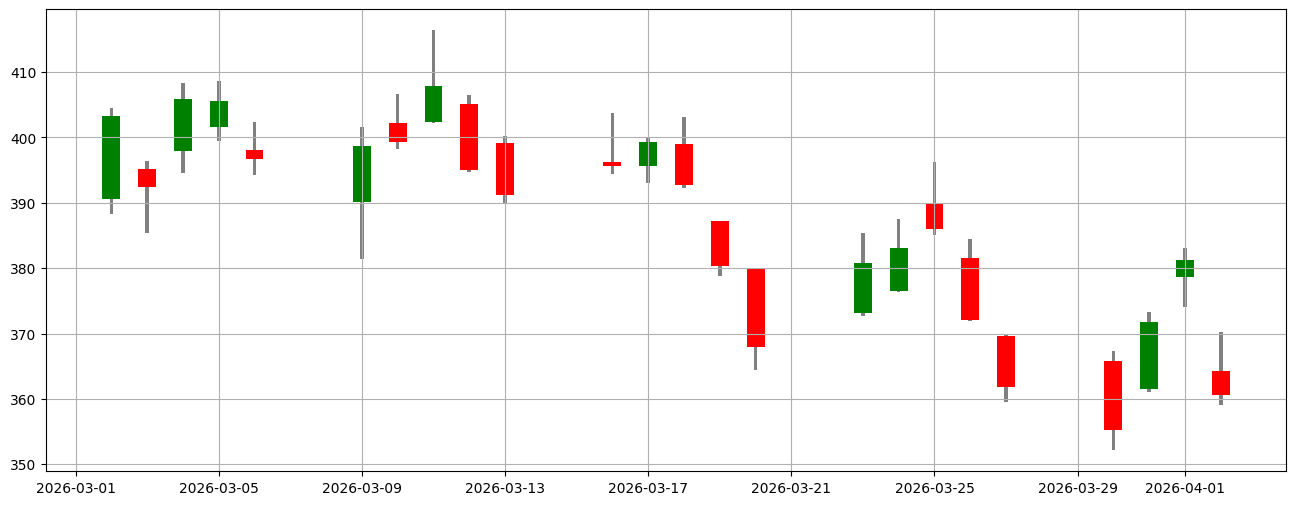

In [5]:
import datos
import importlib
importlib.reload(datos)

tsla_ohlc = datos.OHLC(data[data.index > pd.to_datetime("03-01-2026")])
tsla_ohlc.plot()

## Agregación de subpasos

In [47]:
gbm = SimulacionMonteCarlo.GBM()
gbm.ajustar_parametros(data['close'])

/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:127: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  def ajustar_parametros(self, ts, M = 1):
/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  var_mu, var_sigma = p
/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:132: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

Ajuste de parámetros realizado correctamente.


In [7]:
gbm.mostrar_parametros()

===== Parámetros del modelo =====
T:		1256
N:		1256
Deltat:		1.0
S0:		230.35
M:		1
mu:		0.0010462381678732007
sigma:		0.037214506115364296


<Axes: >

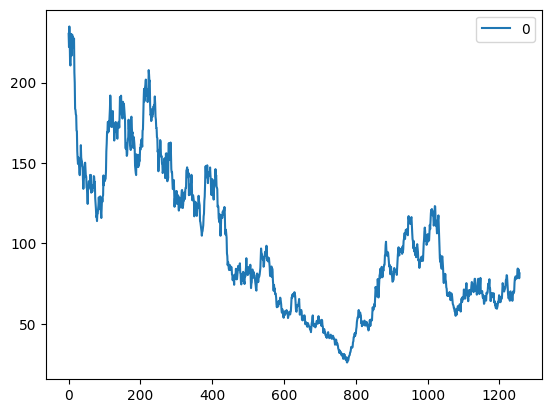

In [8]:
pd.DataFrame(gbm.simular()).plot()

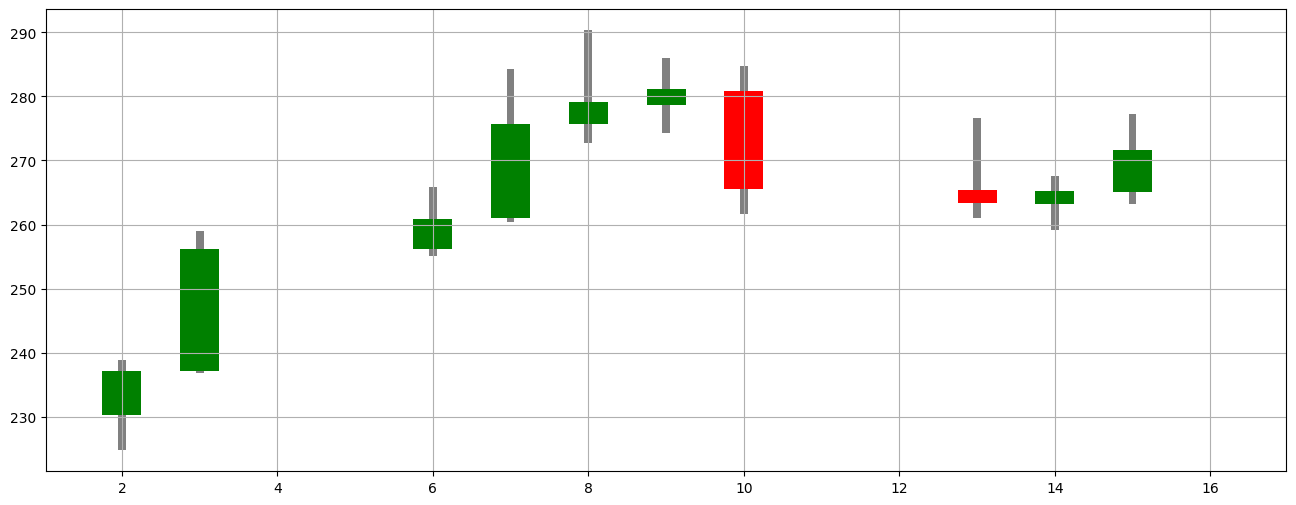

In [53]:
import datos 
importlib.reload(datos)
importlib.reload(SimulacionMonteCarlo)
from datetime import timedelta

gbm.cambiar_escala_temporal(N=10*24*60, Deltat=1/(24*60))
valores = gbm.simular().reshape(-1)
fechas = np.array(datos.next_k_bdays(k=10*24*60+1, start=data.index[-1], delta=timedelta(minutes=1)))
ohlc = datos.OHLC().desde_serie(valores, fechas)
ohlc.plot()